№1 Задача регрессии **(20 баллов)**

Возьмите набор данных согласно своему варианту
(https://cloud.mail.ru/public/AQp5/X3obvSZRo). Датасет представляет собой набор
признаков, признак в последнем столбце является целевым (его надо прогнозировать).
1. Проведите предварительный анализ и подготовку данных, обработайте
пропущенные значения.
2. Проведите статистический анализ, оцените корреляции между признаками, оцените
возможные выбросы в данных, постройте поясняющие графики. Удалите из
рассмотрения признаки, которые не влияют на целевой.
3. Разбейте выборку на тренировочные и тестовые данные (60% на 40%).
4. Для предсказания целевого признака постройте следующие модели, используя
библиотеку sklearn:
a. Линейная регрессия LinearRegression()
b. Случайный лес RandomForestRegressor()
c. Метод ближайших соседей KNeighborsRegressor()
d. Метод опорных векторов SVR()
5. Для каждой модели попытайтесь добиться наилучшего возможного результата
предсказания.
6. Оцените качество работы моделей. Выведите для каждой модели ее score().
Напишите какая модель дала наилучший результат. Выведите ее значение
feature_importances_

Вся работа должна быть аккуратно оформлена в блокноте и защищена преподавателю.

Коэффициент корреляции Пирсона<br/>
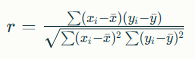

Стандартизация<br/>


Нормализация<br/>
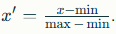

1. Проведите предварительный анализ и подготовку данных, обработайте
пропущенные значения.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Загрузка и подготовка данных
df = pd.read_csv('dataset_var8_num1.csv', header=None, sep=';')
df

,0,1,2,3,4,5,6,7
0,0.113398,-0.217267,0.215167,-0.016867,-1.064496,0.370968,0.268995,11.886437
1,-0.684545,-0.718804,0.157514,0.025171,0.449468,0.405320,-0.239123,-33.260734
2,0.564893,-0.074579,1.157204,-0.389348,1.734190,NaN,-1.250852,58.674006
3,-0.748604,0.843551,0.436197,-0.899861,0.002277,NaN,1.884221,-34.333124
4,0.308416,2.528793,0.563452,0.088222,0.032436,NaN,-1.643330,29.607853
...,...,...,...,...,...,...,...,...
95,1.215433,1.757035,-0.535669,1.685272,-0.454909,NaN,1.642117,56.204279
96,0.105445,1.066696,0.384910,0.228152,-0.008763,NaN,0.844995,12.984287
97,-0.091576,-1.921410,1.053093,-2.039452,0.401763,NaN,-1.012698,20.837647
98,-0.211409,0.400424,0.146756,0.017062,-0.530500,NaN,2.572902,-5.741275


In [43]:
print('Предварительный анализ и подготовка данных')
print("\n======= Информация о датасете =======")
print(df.info())
print("\n======= Пропуски в данных =======")
print(df.isnull().sum())
print("\n======= Описательная статистика =======") 
df.describe()

Предварительный анализ и подготовка данных

======= Информация о датасете =======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       100 non-null    float64
 1   1       100 non-null    float64
 2   2       100 non-null    float64
 3   3       100 non-null    float64
 4   4       95 non-null     float64
 5   5       30 non-null     float64
 6   6       100 non-null    float64
 7   7       100 non-null    float64
dtypes: float64(8)
memory usage: 6.4 KB
None

======= Пропуски в данных =======
0     0
1     0
2     0
3     0
4     5
5    70
6     0
7     0
dtype: int64

======= Описательная статистика =======


,0,1,2,3,4,5,6,7
count,100.000000,100.000000,100.000000,100.000000,95.000000,30.000000,100.000000,100.000000
mean,-0.015087,-0.062730,0.060476,0.022940,0.009851,0.138701,0.062513,1.171854
std,1.079071,0.884791,2.275398,0.934232,1.022725,0.915934,1.002306,72.479434
min,-4.088452,-1.921410,-14.212845,-2.359941,-2.418926,-1.950182,-2.309040,-241.733235
25%,-0.594173,-0.728709,-0.699190,-0.503863,-0.748278,-0.402404,-0.633906,-47.991266
50%,0.060166,-0.048621,0.156478,0.031870,0.032623,0.268823,0.069673,4.931790
75%,0.476788,0.474352,0.820545,0.666486,0.664160,0.590084,0.673443,40.368420
max,2.661735,2.528793,12.410108,2.409821,2.634238,2.361355,2.669669,168.456399


In [29]:
"""
df.info()
Показывается что у 4 столбца 95 non-null, у 5 столбца 30 non-null. Остальные столбцы без пропусков

df.describe()
count подтвержает, что у столбца 4 и 5 есть пропуски.

У целевого столбца (7) слишком большой разброс std = ~72.5 и 
поквинтелям видно широкое распределение, возможны выбросы.
5 столбец имеет слишком много пропусков и исправление средним/медианой, может исказить результат
4 столбец содержит в себе 5 пропусков, поэтому удалить его будет не рациональным решением. 
Более точным будет заполнить пропуски медианой, как более безопасный метод. Выберем его т.к. со средним 
мы исказим распределение признака.
"""

'\ndf.info()\nПоказывается что у 4 столбца 95 non-null, у 5 столбца 30 non-null. Остальные столбцы без пропусков\n\ndf.describe()\ncount подтвержает, что у столбца 4 и 5 есть пропуски.\n\nУ целевого столбца (7) слишком большой разброс std = ~72.5 и \nпоквинтелям видно широкое распределение, возможны выбросы.\n5 столбец имеет слишком много пропусков и исправление средним/медианой, может исказить результат\n4 столбец имеет 5 пропусков и их можно заполниьь медианой, как более безопасный метод. Выберем его т.к. со средним \nмы исказим распределение признака.\n'

In [ ]:
# Анализ пропусков
print("\n======= Обработка пропущенных значений =======")
df = df.drop(columns=[5])

df


======= Обработка пропущенных значений =======


,0,1,2,3,4,6,7
0,0.113398,-0.217267,0.215167,-0.016867,-1.064496,0.268995,11.886437
1,-0.684545,-0.718804,0.157514,0.025171,0.449468,-0.239123,-33.260734
2,0.564893,-0.074579,1.157204,-0.389348,1.734190,-1.250852,58.674006
3,-0.748604,0.843551,0.436197,-0.899861,0.002277,1.884221,-34.333124
4,0.308416,2.528793,0.563452,0.088222,0.032436,-1.643330,29.607853
...,...,...,...,...,...,...,...
95,1.215433,1.757035,-0.535669,1.685272,-0.454909,1.642117,56.204279
96,0.105445,1.066696,0.384910,0.228152,-0.008763,0.844995,12.984287
97,-0.091576,-1.921410,1.053093,-2.039452,0.401763,-1.012698,20.837647
98,-0.211409,0.400424,0.146756,0.017062,-0.530500,2.572902,-5.741275


In [45]:
df = df.fillna(df.median())

In [ ]:
print(df.isnull().sum())

0    0
1    0
2    0
3    0
4    0
6    0
7    0
dtype: int64


In [47]:
df

,0,1,2,3,4,6,7
0,0.113398,-0.217267,0.215167,-0.016867,-1.064496,0.268995,11.886437
1,-0.684545,-0.718804,0.157514,0.025171,0.449468,-0.239123,-33.260734
2,0.564893,-0.074579,1.157204,-0.389348,1.734190,-1.250852,58.674006
3,-0.748604,0.843551,0.436197,-0.899861,0.002277,1.884221,-34.333124
4,0.308416,2.528793,0.563452,0.088222,0.032436,-1.643330,29.607853
...,...,...,...,...,...,...,...
95,1.215433,1.757035,-0.535669,1.685272,-0.454909,1.642117,56.204279
96,0.105445,1.066696,0.384910,0.228152,-0.008763,0.844995,12.984287
97,-0.091576,-1.921410,1.053093,-2.039452,0.401763,-1.012698,20.837647
98,-0.211409,0.400424,0.146756,0.017062,-0.530500,2.572902,-5.741275


2. Проведите статистический анализ, оцените корреляции между признаками, оцените
возможные выбросы в данных, постройте поясняющие графики. Удалите из
рассмотрения признаки, которые не влияют на целевой.

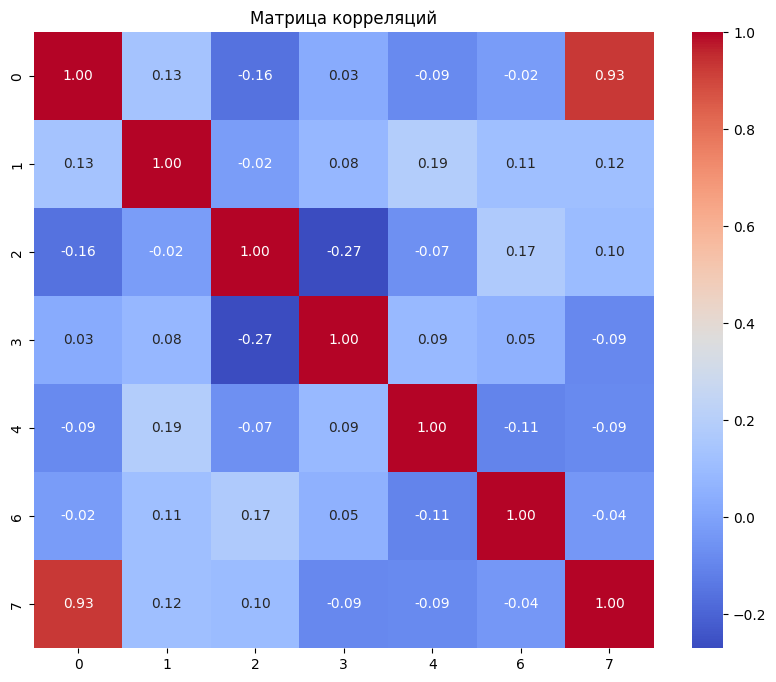

In [48]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляций')
plt.show()

In [49]:
"""
Признак 0 имеет очень высокую корреляцию с целевым признаком 7 (0.93)
Удаление признаов применяется только в случае высокой корреляции 
между самими признаками, а не с сильной связью с целевым признаком
"""

'\nПризнак 0 имеет очень высокую корреляцию с целевым признаком 7 (0.93)\nУдаление признаов применяется только в случае высокой корреляции \nмежду самими признаками, а не с сильной связью с целевым признаком\n'

In [50]:
target_col = 7 
for col in df.columns.drop(target_col):
    correlation = df[target_col].corr(df[col])
    print(f'Корреляция между столбцами {col} и {target_col}: {correlation:.4f}')

Корреляция между столбцами 0 и 7: 0.9262
Корреляция между столбцами 1 и 7: 0.1155
Корреляция между столбцами 2 и 7: 0.0990
Корреляция между столбцами 3 и 7: -0.0918
Корреляция между столбцами 4 и 7: -0.0864
Корреляция между столбцами 6 и 7: -0.0389


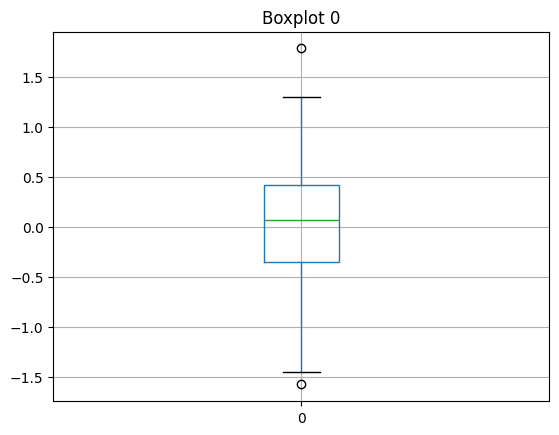

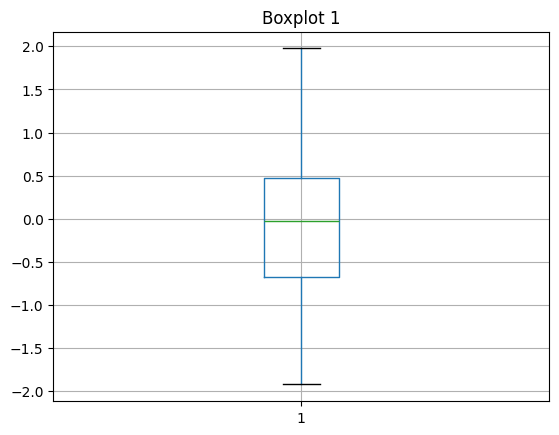

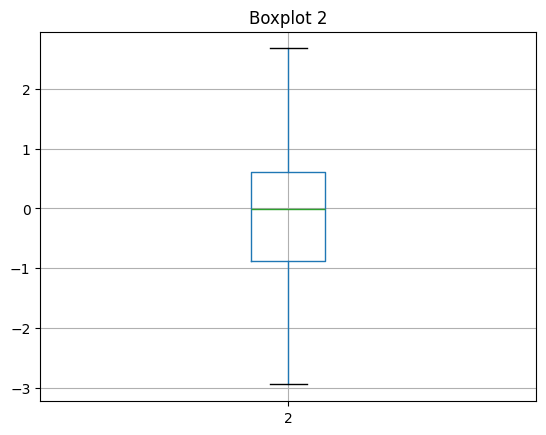

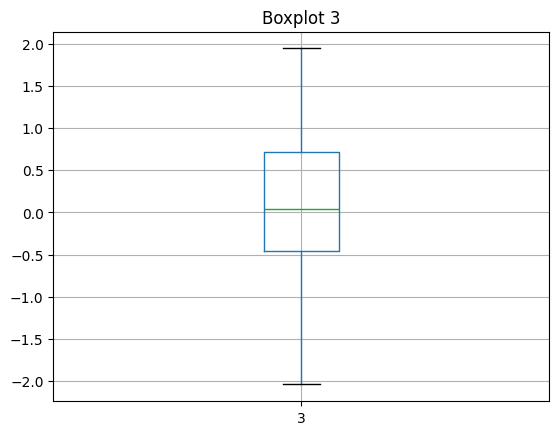

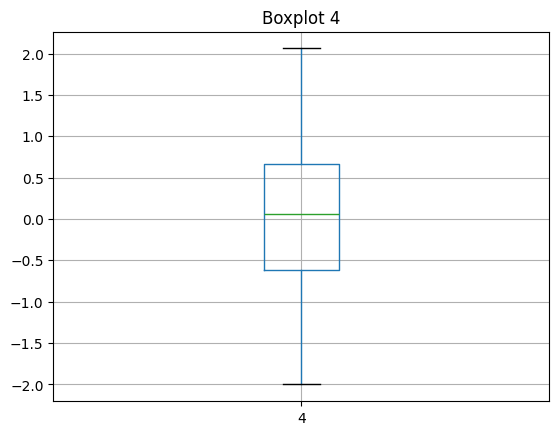

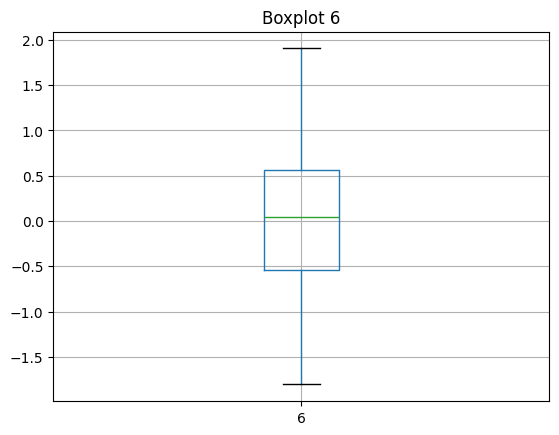

In [54]:
import matplotlib.pyplot as plt

# Целевой столбец — 7
target_col = 7

feature_cols = df.columns.drop(target_col)

# Удаление всех выбросов, которые находятся за пределами этого промежутка
# (df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR) 
# Дальше рисуем рисуем по текущему столбцу после удаления выбросов
# Q1 - 1-ый квартиль(25%)
# Q3 - 3-ый квартиль(75%) 
# IQR - межквартильный размах 

for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

    df.boxplot(column=col)
    plt.title(f'Boxplot {col}')
    plt.show()

In [55]:
# Полдсчет количества строк и количества столбцов после обработки выбросов
df.shape

(79, 7)

3. Разбейте выборку на тренировочные и тестовые данные (60% на 40%).

In [57]:
X = df.drop(columns=[7]).values     # Все столбцы кроме последнего
y = df[7].values                    # Последний столбец

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
# Проверим насколько разделилось
print(f'Размер обучающей выборки: {X_train.shape}, Размер тестовой выборки: {X_test.shape}')
print(f'Размер обучающей выборки (целевая): {y_train.shape}, Размер тестовой выборки (целевая): {y_test.shape}')

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Размер обучающей выборки: (47, 6), Размер тестовой выборки: (32, 6)
Размер обучающей выборки (целевая): (47,), Размер тестовой выборки (целевая): (32,)


In [ ]:
"""
Масштабирование признаков помогает улучшить сходимость и производительность моделей машинного обучения,
особенно для алгоритмов, чувствительных к масштабу данных, таких как KNN и SVM.
"""

4. Для предсказания целевого признака постройте следующие модели, используя
библиотеку sklearn:<br/>
a. Линейная регрессия LinearRegression()<br/>
b. Случайный лес RandomForestRegressor()<br/>
c. Метод ближайших соседей KNeighborsRegressor()<br/>
d. Метод опорных векторов SVR()<br/>

5. Для каждой модели попытайтесь добиться наилучшего возможного результата
предсказания.

In [ ]:
"""
train_r2 - качество на обучение (видно, насколько хорошо модель подогналась к train)
test_r2 - качество на тесте
mae - средняя абсолютная ошибка
mse - средняя квадратичная ошибка
rmse - корень от mse
"""

Линейная регрессия LinearRegression()

In [73]:
# Обучение модели линейной регрессии
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Предсказания
y_train_pred_lr = lr.predict(X_train_scaled)
y_test_pred_lr = lr.predict(X_test_scaled)

# Оценка модели
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)
print(f"train R²: {train_r2_lr:.10f}")
print(f"test R²: {test_r2_lr:.10f}")

train R²: 0.9980477162
test R²: 0.9879864070


Случайный лес RandomForestRegression()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Настройка гиперпараметров для RandomForestRegressor
param_grid_rf = {
    "n_estimators": [100, 200, 300], # Количество деревьев в лесу
    "max_depth": [None, 10, 20], # Максимальная глубина дерева
    "min_samples_split": [2, 5, 10], # Минимальное количество образцов, необходимое для разбиения узла
    "min_samples_leaf": [5, 7, 10] # Минимальное количество образцов, необходимое для листового узла
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, 
                       scoring='r2', cv=5, n_jobs=-1, verbose=2)

# Обучение модели с подбором гиперпараметров
grid_rf.fit(X_train_scaled, y_train)

# Лучшие гиперпараметры
best_params_rf = grid_rf.best_params_
print("Лучшие гиперпараметры для RandomForestRegressor:", best_params_rf)

# Предсказания с лучшей моделью
y_train_pred_rf = grid_rf.predict(X_train_scaled)
y_test_pred_rf = grid_rf.predict(X_test_scaled)

# Оценка модели
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print(f"train R²: {train_r2_rf:.10f}")
print(f"test R²: {test_r2_rf:.10f}")


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Лучшие гиперпараметры для RandomForestRegressor: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 100}
train R²: 0.8912867808
test R²: 0.6642188305


Метод ближайших соседей KNN()

In [119]:
from sklearn.pipeline import Pipeline

# Сначала масштабирование, затем KNN
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

# Настройка гиперпараметров для KNN
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],  # количество соседей
    'knn__weights': ['uniform', 'distance'],            # равные веса или по расстоянию
    'knn__p': [1, 2]    # метрика: 1 - Манхэттен, 2 - Евклид
}


grid_knn = GridSearchCV(
    pipe_knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Обучение модели с подбором гиперпараметров
grid_knn.fit(X_train, y_train)

# Лучшие гиперпараметры
best_params_knn = grid_knn.best_params_
print("Лучшие гиперпараметры для KNeighborsRegressor:", best_params_knn)

# Предсказания с лучшей моделью
y_train_pred_knn = grid_knn.predict(X_train)
y_test_pred_knn = grid_knn.predict(X_test)

# Оценка модели
train_r2_knn = r2_score(y_train, y_train_pred_knn)
test_r2_knn = r2_score(y_test, y_test_pred_knn)

print(f"train R²: {train_r2_knn:.10f}")
print(f"test R²: {test_r2_knn:.10f}")


Лучшие гиперпараметры для KNeighborsRegressor: {'knn__n_neighbors': 9, 'knn__p': 1, 'knn__weights': 'distance'}
train R²: 1.0000000000
test R²: 0.3882372950


Метод опорных векторов SVR()

In [116]:
# Сначала масштабирование, затем SVR
pipe_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

# Настройка гиперпараметров для SVR
param_grid_svr = {
    'svr__kernel': ['rbf'], # тип ядра
    'svr__C': [1, 10, 100], # коэффициент регулирования
    'svr__gamma': ['scale'] # параметр ядра для rbf  
}

grid_svr = GridSearchCV(
    pipe_svr,
    param_grid=param_grid_svr,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Обучение модели с подбором гиперпараметров
grid_svr.fit(X_train, y_train)

# Лучшие гиперпараметры
best_params_svr = grid_svr.best_params_
print("Лучшие гиперпараметры для SVR:", best_params_svr)

# Предсказания с лучшей моделью
y_train_pred_svr = grid_svr.predict(X_train)
y_test_pred_svr = grid_svr.predict(X_test)

# Оценка модели
train_r2_svr = r2_score(y_train, y_train_pred_svr)
test_r2_svr = r2_score(y_test, y_test_pred_svr)

print(f"train R²: {train_r2_svr:.10f}")
print(f"test R²: {test_r2_svr:.10f}")

Лучшие гиперпараметры для SVR: {'svr__C': 1, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}
train R²: 0.8766990519
test R²: 0.2800867851


6. Оцените качество работы моделей. Выведите для каждой модели ее score().
Напишите какая модель дала наилучший результат. Выведите ее значение
feature_importances_

In [120]:
import pandas as pd
import matplotlib.pyplot as plt

# Сводим результаты по моделям в одну таблицу
results = [
    ['LinearRegression', train_r2_lr,  test_r2_lr],
    ['RandomForest',     train_r2_rf,  test_r2_rf],
    ['KNeighbors',       train_r2_knn, test_r2_knn],
    ['SVR',              train_r2_svr, test_r2_svr]
]

results_df = pd.DataFrame(results, columns=['Модель', 'Train Score', 'Test Score'])
print(results_df)

# Словарь "имя -> объект модели"
models = {
    'LinearRegression': lr,
    'RandomForest':     grid_rf.best_estimator_,
    'KNeighbors':       grid_knn.best_estimator_,
    'SVR':              grid_svr.best_estimator_
}

# Находим лучшую модель по Test Score
best_idx = results_df['Test Score'].idxmax()
best_model_name = results_df.loc[best_idx, 'Модель']
best_model = models[best_model_name]
best_test_score = results_df.loc[best_idx, 'Test Score']

print(f"\nНаилучший результат на тесте показала модель: {best_model_name}")
print(f"Test R² = {best_test_score:.6f}")

# feature_importances_ для лучшей модели, только для RandomForest
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    fi = pd.DataFrame({
        'Признак': df.drop(columns=[7]).columns,   # или свои имена признаков
        'Важность': importances
    }).sort_values('Важность', ascending=False)

    print("\nВажность признаков для лучшей модели:")
    print(fi.to_string(index=False))

    plt.figure(figsize=(8, 5))
    top = fi.head(10)
    plt.barh(top['Признак'], top['Важность'])
    plt.xlabel('Важность признака')
    plt.title('Топ-10 признаков по важности')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("\nfeature_importances_ недоступно для этой модели")


             Модель  Train Score  Test Score
0  LinearRegression     0.998048    0.987986
1      RandomForest     0.891287    0.664219
2        KNeighbors     1.000000    0.388237
3               SVR     0.876699    0.280087

Наилучший результат на тесте показала модель: LinearRegression
Test R² = 0.987986

feature_importances_ недоступно для этой модели


№2 Задача классификации **(20 баллов)**
Возьмите набор данных согласно своему варианту
(https://cloud.mail.ru/public/MWZh/DQkbAHKmi). Датасет представляет собой набор
признаков, в последнем столбце указан класс объекта.
1. Проведите предварительный анализ и подготовку данных, обработайте
пропущенные значения.
2. Проведите статистический анализ, оцените корреляции между признаками, оцените
возможные выбросы в данных, постройте поясняющие графики. Удалите из
рассмотрения признаки, которые не влияют на целевой.
3. Разбейте выборку на тренировочные и тестовые данные (60% на 40%).
4. Для предсказания класса постройте две модели, используя библиотеку sklearn:
a. Случайный лес RandomForestClassifier()
b. Метод ближайших соседей KNeighborsClassifier()
5. Для каждой модели попытайтесь добиться наилучшего возможного результата
предсказания.
6. Оцените качество работы моделей. Выведите метрики модели. Напишите какая
модель дала наилучший результат.

Вся работа должна быть аккуратно оформлена в блокноте и защищена преподавателю.

1. Проведите предварительный анализ и подготовку данных, обработайте
пропущенные значения.

In [97]:
# Загрузка и подготовка данных
df = pd.read_csv('dataset_var8_num2.csv', header=None, sep=';')
df

,0,1,2,3,4,5,6,7
0,-0.624062,0.778513,-0.034999,1.668018,-0.613678,1.209992,1.668018,2
1,-0.212489,-1.690497,0.476216,-0.285705,-2.012242,-2.266745,-0.285705,1
2,2.186700,-0.965655,1.686778,-1.729750,4.895443,2.373926,-1.729750,0
3,-0.533210,-1.843536,-0.192996,2.862843,-1.716288,1.066370,2.862843,2
4,-1.155205,0.909580,-0.722481,1.929296,-1.618793,6.337379,1.929296,2
...,...,...,...,...,...,...,...,...
95,1.190682,2.050559,1.058045,-0.272913,-0.476906,-1.433056,-0.272913,1
96,NaN,-1.634836,-0.639180,-0.367878,-0.623763,-1.177879,-0.367878,1
97,1.572176,0.170844,0.145407,-1.707475,2.679587,0.399267,-1.707475,0
98,-0.403967,-1.200083,0.130981,-0.058759,0.482217,0.689224,-0.058759,0


In [98]:
print('Предварительный анализ и подготовка данных')
print("\n======= Информация о датасете =======")
print(df.info())
print("\n======= Пропуски в данных =======")
print(df.isnull().sum())
print("\n======= Описательная статистика =======") 
df.describe()

Предварительный анализ и подготовка данных

======= Информация о датасете =======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       95 non-null     float64
 1   1       95 non-null     float64
 2   2       100 non-null    float64
 3   3       100 non-null    float64
 4   4       100 non-null    float64
 5   5       100 non-null    float64
 6   6       100 non-null    float64
 7   7       100 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 6.4 KB
None

======= Пропуски в данных =======
0    5
1    5
2    0
3    0
4    0
5    0
6    0
7    0
dtype: int64

======= Описательная статистика =======


,0,1,2,3,4,5,6,7
count,95.000000,95.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.433048,0.001407,-0.125324,-0.363850,0.848939,0.464307,-0.363850,1.010000
std,1.295583,1.079903,0.956781,1.261365,1.878338,1.884047,1.261365,0.810225
min,-2.177391,-2.172377,-2.133489,-2.341443,-3.386762,-9.830304,-2.341443,0.000000
25%,-0.712306,-0.697073,-0.732506,-1.351109,-0.501900,-0.557030,-1.351109,0.000000
50%,0.585254,-0.040557,-0.050642,-0.671539,0.584644,0.753136,-0.671539,1.000000
75%,1.529887,0.701613,0.490600,0.234845,2.003196,1.119237,0.234845,2.000000
max,2.717623,2.585381,2.500100,2.862843,4.895443,6.901927,2.862843,2.000000


In [ ]:
"""
df.info()
Показывается что у 0 и 1 столбца 95 non-null. Остальные столбцы без пропусков

df.describe()
count подтвержает, что у столбца 0 и 1 есть пропуски.

У целевого столбца (7) ...
"""

In [99]:
df = df.fillna(df.median())

In [100]:
print(df.isnull().sum())

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
dtype: int64


In [101]:
df

,0,1,2,3,4,5,6,7
0,-0.624062,0.778513,-0.034999,1.668018,-0.613678,1.209992,1.668018,2
1,-0.212489,-1.690497,0.476216,-0.285705,-2.012242,-2.266745,-0.285705,1
2,2.186700,-0.965655,1.686778,-1.729750,4.895443,2.373926,-1.729750,0
3,-0.533210,-1.843536,-0.192996,2.862843,-1.716288,1.066370,2.862843,2
4,-1.155205,0.909580,-0.722481,1.929296,-1.618793,6.337379,1.929296,2
...,...,...,...,...,...,...,...,...
95,1.190682,2.050559,1.058045,-0.272913,-0.476906,-1.433056,-0.272913,1
96,0.585254,-1.634836,-0.639180,-0.367878,-0.623763,-1.177879,-0.367878,1
97,1.572176,0.170844,0.145407,-1.707475,2.679587,0.399267,-1.707475,0
98,-0.403967,-1.200083,0.130981,-0.058759,0.482217,0.689224,-0.058759,0


2. Проведите статистический анализ, оцените корреляции между признаками, оцените
возможные выбросы в данных, постройте поясняющие графики. Удалите из
рассмотрения признаки, которые не влияют на целевой.

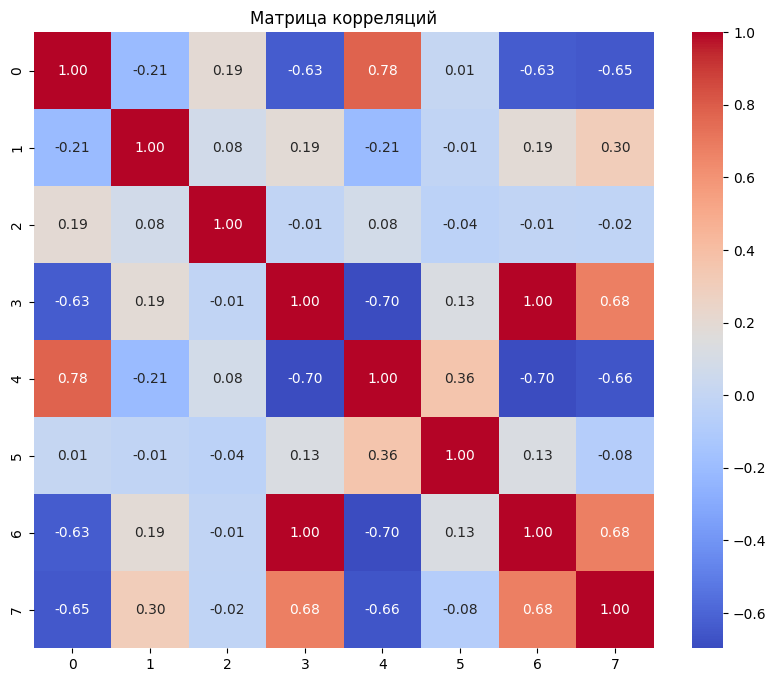

In [94]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляций')
plt.show()

In [102]:
df = df.drop(columns=df.columns[3])
df.dropna(axis=0, how='any', inplace=True)
df

,0,1,2,4,5,6,7
0,-0.624062,0.778513,-0.034999,-0.613678,1.209992,1.668018,2
1,-0.212489,-1.690497,0.476216,-2.012242,-2.266745,-0.285705,1
2,2.186700,-0.965655,1.686778,4.895443,2.373926,-1.729750,0
3,-0.533210,-1.843536,-0.192996,-1.716288,1.066370,2.862843,2
4,-1.155205,0.909580,-0.722481,-1.618793,6.337379,1.929296,2
...,...,...,...,...,...,...,...
95,1.190682,2.050559,1.058045,-0.476906,-1.433056,-0.272913,1
96,0.585254,-1.634836,-0.639180,-0.623763,-1.177879,-0.367878,1
97,1.572176,0.170844,0.145407,2.679587,0.399267,-1.707475,0
98,-0.403967,-1.200083,0.130981,0.482217,0.689224,-0.058759,0


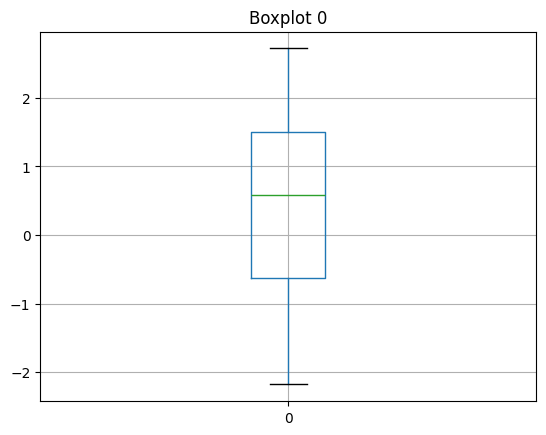

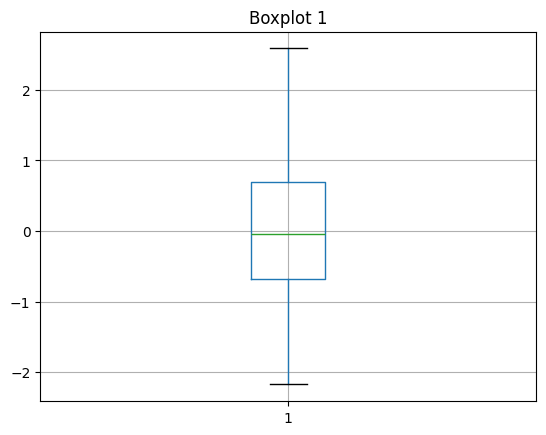

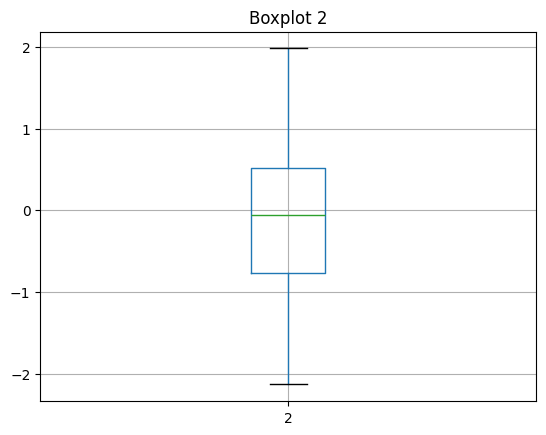

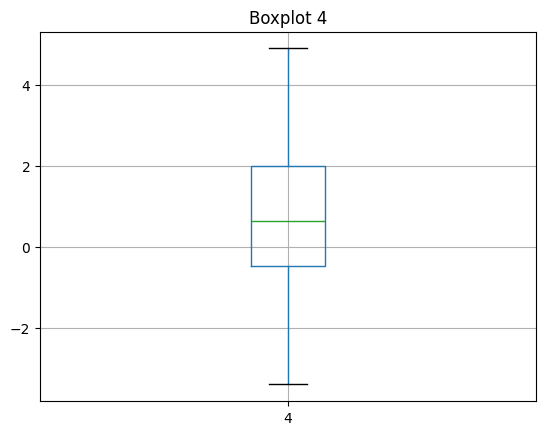

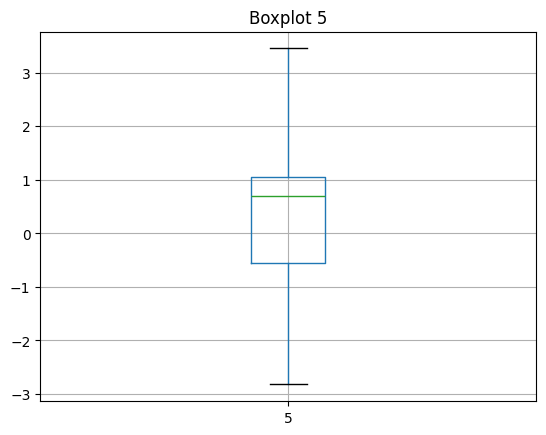

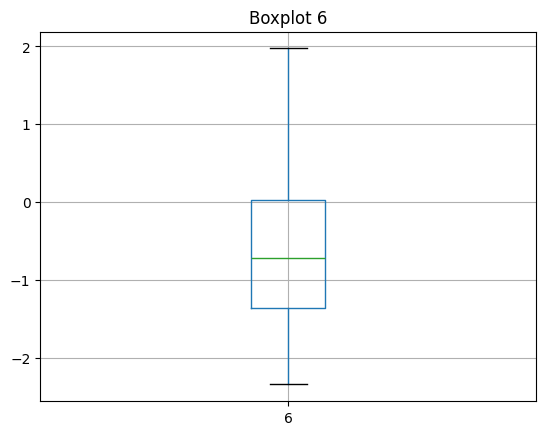

In [104]:
# Целевой столбец — 7
target_col = 7

feature_cols = df.columns.drop(target_col)

for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

    df.boxplot(column=col)
    plt.title(f'Boxplot {col}')
    plt.show()

In [105]:
df.shape

(92, 7)

3. Разбейте выборку на тренировочные и тестовые данные (60% на 40%).

In [106]:
X = df.drop(columns=[7]).values     # Все столбцы кроме последнего
y = df[7].values                    # Последний столбец

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
# Проверим насколько разделилось
print(f'Размер обучающей выборки: {X_train.shape}, Размер тестовой выборки: {X_test.shape}')
print(f'Размер обучающей выборки (целевая): {y_train.shape}, Размер тестовой выборки (целевая): {y_test.shape}')

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Размер обучающей выборки: (55, 6), Размер тестовой выборки: (37, 6)
Размер обучающей выборки (целевая): (55,), Размер тестовой выборки (целевая): (37,)


4. Для предсказания класса постройте две модели, используя библиотеку sklearn:<br/>
a. Случайный лес RandomForestClassifier()<br/>
b. Метод ближайших соседей KNeighborsClassifier()<br/>
5. Для каждой модели попытайтесь добиться наилучшего возможного результата
предсказания.

In [108]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Настройка гиперпараметров для RandomForestClassifier
param_grid_rfc = {
    "n_estimators": [100, 150, 200], # Количество деревьев в лесу
    "max_depth": [None, 10, 20],  # Максимальная глубина дерева
    "min_samples_split": [2, 5, 10], # Минимальное количество образцов, необходимое для разбиения узла
    "min_samples_leaf": [1, 2, 4] # Минимальное количество образцов, необходимое для листового узла
}

rfc = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid_rfc, 
                       scoring='accuracy', cv=5)

# Обучение модели с подбором гиперпараметров
grid_rfc.fit(X_train, y_train)

# Лучшие гиперпараметры
best_params_rfc = grid_rfc.best_params_
print("Лучшие гиперпараметры для KNeighborsRegressor:", best_params_rfc)

y_pred_rfc = grid_rfc.best_estimator_.predict(X_test)

print(classification_report(y_test, y_pred_rfc))

Лучшие гиперпараметры для KNeighborsRegressor: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.46      0.86      0.60         7
           1       0.92      0.85      0.88        13
           2       0.92      0.65      0.76        17

    accuracy                           0.76        37
   macro avg       0.76      0.78      0.75        37
weighted avg       0.83      0.76      0.77        37



In [131]:
# Сначала масштабирование, затем KNN
from sklearn.neighbors import KNeighborsClassifier


pipe_knn_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Настройка гиперпараметров для RandomForestClassifier
param_grid_knn_clf = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

grid_knn_clf = GridSearchCV(
    pipe_knn_clf,
    param_grid=param_grid_knn_clf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Обучение модели с подбором гиперпараметров
grid_knn_clf.fit(X_train, y_train)

# Лучшие гиперпараметры
best_params_knn_clf = grid_knn_clf.best_params_
print("Лучшие гиперпараметры для KNeighborsRegressor:", best_params_knn_clf)

y_pred_knn_clf = grid_knn_clf.best_estimator_.predict(X_test)

print(classification_report(y_test, y_pred_knn_clf))

Лучшие гиперпараметры для KNeighborsRegressor: {'knn__n_neighbors': 11, 'knn__p': 1, 'knn__weights': 'uniform'}
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         7
           1       1.00      0.85      0.92        13
           2       1.00      0.71      0.83        17

    accuracy                           0.81        37
   macro avg       0.83      0.85      0.80        37
weighted avg       0.91      0.81      0.83        37



6. Оцените качество работы моделей. Выведите метрики модели. Напишите какая
модель дала наилучший результат.

In [ ]:
"""
Вывод
"""